
# 05. 통합 시스템 I1: 읽기 + 기억 + 판단

규칙 세계 v2(누구를 믿을지 경험으로 배우는 세계). 모든 시스템은 **문장만** 입력으로 받는다(정답 구조 없음).

| 시스템 | 읽기 | 기억·판단 | 사람이 정해 준 것 |
|---|---|---|---|
| 코드 (B3/B4) | NLI 분류기 → 설계된 사실 형식 | 베이즈 최적 코드 | 사실 형식, 생성 규칙 |
| N2 | NLI 분류기 → 설계된 사실 형식 | 학습 | 사실 형식 |
| **I1** | **v1에서 키운 읽기 부품 (재학습 없음)** | **학습** | **틀(대칭성)만** |

표준 세계는 seed 42, 오설정 세계는 seed 42·43이다.


In [1]:

import json
import matplotlib.pyplot as plt
from cognitive_lab import summary as S
from cognitive_lab import viz as V

V.setup()

def score(agent, seed, suffix):
    path = S.RESULTS / f"world-v2_{agent}_test_seed-{seed}{suffix}.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.exists() else None

conditions = [("표준 세계 · seed 42", 42, "_text", "b3-bayes-h01", "n2", "o2"),
              ("오설정 세계 · seed 42", 42, "_mis_text", "b4-joint", "n2-mis", "o2-mis"),
              ("오설정 세계 · seed 43", 43, "_mis_text", "b4-joint", "n2-mis", "o2-mis")]



## 1. 점수 비교

점선은 모든 것을 아는 신탁이다. 학습자는 이 선에 닿을 수 없다(처음 보는 사람은 경험이 쌓여야 판단할 수 있다).


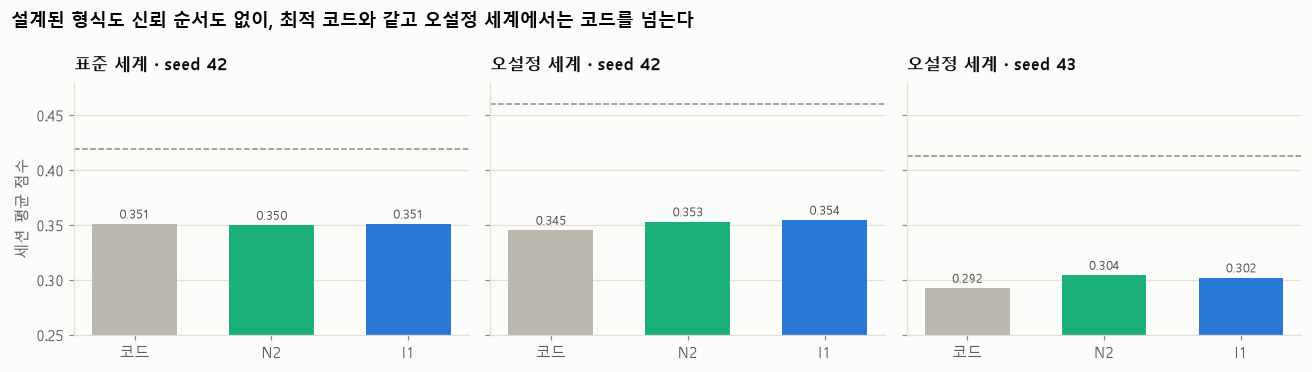

In [2]:

systems = [("코드 (설계 형식 + 베이즈)", 3, V.NEUTRAL), ("N2 (설계 형식 + 학습)", 4, V.AQUA), ("I1 (설계 형식 없음)", None, V.BLUE)]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (title, seed, suffix, code, n2, oracle) in zip(axes, conditions):
    names = {3: code, 4: n2}
    for i, (label, slot, color) in enumerate(systems):
        agent = "i1" if slot is None else names[slot]
        r = score(agent, seed, suffix)
        if r is None:
            continue
        value = r["overall"]["mean_score"]
        ax.bar(i, value, width=0.62, color=color)
        ax.text(i, value + 0.005, f"{value:.3f}", ha="center", fontsize=8.5, color=V.TEXT_SECONDARY)
    o = score(oracle, seed, suffix) or score(oracle, seed, suffix.replace("_text", ""))
    if o:
        ax.axhline(o["overall"]["mean_score"], color=V.MUTED, linestyle="--", linewidth=1)
    ax.set_xticks(range(3), ["코드", "N2", "I1"])
    ax.set_ylim(0.25, 0.48)
    ax.grid(axis="x", visible=False)
    ax.set_title(title, fontsize=11, pad=8)
axes[0].set_ylabel("세션 평균 점수")
fig.suptitle("설계된 형식도 신뢰 순서도 없이, 최적 코드와 같고 오설정 세계에서는 코드를 넘는다",
             x=0.01, ha="left", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()



## 2. 세션 안에서 배우는 모습 (표준 세계, seed 42)


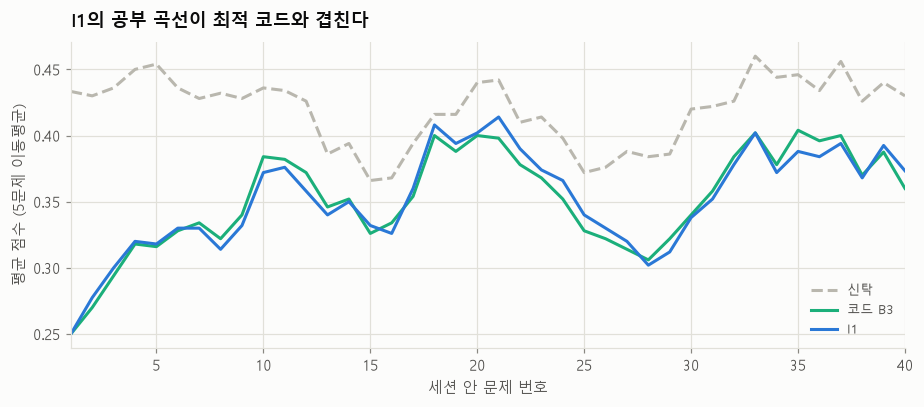

In [3]:

fig, ax = plt.subplots(figsize=(8.5, 3.8))
for agent, label, color, dash in [("o2", "신탁", V.NEUTRAL, "--"), ("b3-bayes-h01", "코드 B3", V.AQUA, "-"), ("i1", "I1", V.BLUE, "-")]:
    r = score(agent, 42, "_text") or score(agent, 42, "")
    if r is None:
        continue
    totals, counts = [0.0] * 40, [0] * 40
    for record in r["predictions"]:
        totals[record["index"]] += record["score"]
        counts[record["index"]] += 1
    curve = [t / c for t, c in zip(totals, counts)]
    smooth = [sum(curve[max(0, i - 2): i + 3]) / len(curve[max(0, i - 2): i + 3]) for i in range(40)]
    ax.plot(range(1, 41), smooth, dash, color=color, label=label)
ax.set_xlim(1, 40)
ax.set_xlabel("세션 안 문제 번호")
ax.set_ylabel("평균 점수 (5문제 이동평균)")
ax.set_title("I1의 공부 곡선이 최적 코드와 겹친다", pad=10)
ax.legend(loc="lower right", fontsize=8.5)
fig.tight_layout()
plt.show()



## 3. 정리와 다음 질문

- **I1은 작동한다.** v1에서 키운 읽기 부품을 재학습 없이 옮기고, 사람이 설계한 사실 형식이나 신뢰 순서 없이 틀만 주었다. 그래도 표준 세계에서 최적 코드와 같고(0.351), 오설정 세계에서는 코드보다 약 +0.009 높다(seed 2개).
- **하지만 N2보다 낫지는 않다.** 이 세계에서는 설계된 사실 형식 (문, 열쇠, 긍정/부정)이 판단에 필요한 정보를 하나도 버리지 않기 때문이다. 학습된 형식이 이길 수 있는 곳은 **설계된 형식이 정보를 버리는 세계**뿐이다.
- **다음 실험 후보**: 말투에 신뢰 단서가 있는 세계. 예를 들어 믿을 만한 사람은 "확실히 ~야"라고 하고, 따라쟁이는 "누가 그러던데 ~래"라고 한다. 설계된 형식은 이런 말투를 버리지만, 학습된 형식은 담을 수 있다.
